<a href="https://colab.research.google.com/github/zukhrafarshadz-sudo/Phishing-Email-Detection/blob/main/ST20318986_Final_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Phishing Email Detection — Full Research Pipeline
**MSc Dissertation | Cardiff Metropolitan University**

**Student: Zukhraf Arshad | ST20318986**

---
## 📋 Notebook Structure
| Section | Content |
|---------|---------|
| **0** | Setup & Installation |
| **1** | Dataset Loading & Inspection |
| **2** | Exploratory Data Analysis (EDA) |
| **3** | Preprocessing & Feature Engineering |
| **4** | Classical ML Models (NB · LR · SVM · RF · XGBoost) |
| **5** | Deep Learning (LSTM · BiLSTM) |
| **6** | Transformer Models (DistilBERT · RoBERTa) |
| **7** | Improved Ensemble Model |
| **8** | Full Results Comparison & Visualisation |



## Section 0 — Setup & Installation

In [1]:
# ── Installing all required libraries ──────────────────────────────
!pip install -q "numpy>=1.24,<2.0" --force-reinstall


!pip install -q \
    "transformers==4.44.2" \
    "accelerate>=0.26.0" \
    "datasets>=2.18.0" \
    "scikit-learn>=1.3.0" \
    "imbalanced-learn>=0.11.0" \
    "xgboost>=2.0.0" \
    "wordcloud>=1.9.0" \
    "seaborn>=0.13.0"

print("\n✅ All libraries installed successfully.")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.2

In [2]:
# ── Dataset paths──────
import os
from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/phishing_datasets'

# All 11 dataset filenames
EXPECTED_FILES = [
    'Enron.csv', 'CEAS_08.csv', 'SpamAssasin.csv', 'TREC_07.csv',
    'TREC_06.csv', 'TREC_05.csv', 'Ling.csv', 'Nigerian_5.csv',
    'Nazario_5.csv', 'Nazario.csv', 'Nigerian_Fraud.csv'
]

print("Checking files in Google Drive...")
found, missing = 0, 0
for fname in EXPECTED_FILES:
    path = os.path.join(DRIVE_PATH, fname)
    exists = os.path.exists(path)
    status = '✅' if exists else ' MISSING'
    print(f"  {status}  {fname}")
    if exists: found += 1
    else: missing += 1

print(f"\n{found}/11 files found | {missing} missing")
if missing > 0:
    print("    Missing files will be skipped — remaining datasets will still run.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking files in Google Drive...
  ✅  Enron.csv
  ✅  CEAS_08.csv
  ✅  SpamAssasin.csv
  ✅  TREC_07.csv
  ✅  TREC_06.csv
  ✅  TREC_05.csv
  ✅  Ling.csv
  ✅  Nigerian_5.csv
  ✅  Nazario_5.csv
  ✅  Nazario.csv
  ✅  Nigerian_Fraud.csv

11/11 files found | 0 missing


In [3]:
# ── Global imports ──────────────────────────────────────────────
import warnings, re, time, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
from sklearn.inspection import permutation_importance
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    Trainer, TrainingArguments
)
import datasets as hf_datasets

from wordcloud import WordCloud
from scipy.sparse import hstack

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Imports done | Device: {DEVICE}")

# Colour palette for plots
PALETTE = {'Legitimate': '#2196F3', 'Phishing': '#F44336'}
MODEL_COLORS = ['#3F51B5','#00BCD4','#FF5722','#4CAF50','#9C27B0',
                '#FF9800','#E91E63','#795548','#607D8B']


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7c0789fe4900>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


✅ Imports done | Device: cuda


In [4]:
# ── RAM monitor helper ────────────
import psutil, os

def ram_usage():
    proc   = psutil.Process(os.getpid())
    used   = proc.memory_info().rss / 1e9
    total  = psutil.virtual_memory().total / 1e9
    avail  = psutil.virtual_memory().available / 1e9
    print(f"RAM used by process: {used:.1f} GB")
    print(f"Total system RAM:    {total:.1f} GB")
    print(f"Available RAM:       {avail:.1f} GB")
    pct = used/total*100
    status = '🟢 OK' if pct < 60 else '🟡 CAUTION' if pct < 80 else '🔴 DANGER'
    print(f"Usage: {pct:.0f}%  {status}")

ram_usage()


RAM used by process: 1.5 GB
Total system RAM:    13.6 GB
Available RAM:       11.0 GB
Usage: 11%  🟢 OK


---
## Section 1 — Dataset Loading & Initial Inspection

In [5]:
# ── Load ALL 11 datasets ─────────────────────────────────────────
import pandas as pd, numpy as np, os

DRIVE_PATH = '/content/drive/MyDrive/phishing_datasets'

DATASET_FILES = {
    'Enron':          (os.path.join(DRIVE_PATH,'Enron.csv'),          'standard'),
    'CEAS_08':        (os.path.join(DRIVE_PATH,'CEAS_08.csv'),         'standard'),
    'SpamAssassin':   (os.path.join(DRIVE_PATH,'SpamAssasin.csv'),     'standard'),
    'TREC_07':        (os.path.join(DRIVE_PATH,'TREC_07.csv'),         'standard'),
    'Ling':           (os.path.join(DRIVE_PATH,'Ling.csv'),            'standard'),
    'Nigerian_5':     (os.path.join(DRIVE_PATH,'Nigerian_5.csv'),      'standard'),
    'Nazario_5':      (os.path.join(DRIVE_PATH,'Nazario_5.csv'),       'standard'),
    'TREC_06':        (os.path.join(DRIVE_PATH,'TREC_06.csv'),         'python'),
    'TREC_05':        (os.path.join(DRIVE_PATH,'TREC_05.csv'),         'python'),
    'Nazario':        (os.path.join(DRIVE_PATH,'Nazario.csv'),         'standard'),  # phishing-only
    'Nigerian_Fraud': (os.path.join(DRIVE_PATH,'Nigerian_Fraud.csv'),  'standard'),  # phishing-only
}

all_dfs = []
summary_rows = []

for name, (path, engine) in DATASET_FILES.items():
    if not os.path.exists(path):
        print(f"⚠️  {name}: file not found at {path}")
        continue
    try:
        if engine == 'python':
            df = pd.read_csv(path, engine='python', on_bad_lines='skip', encoding='latin-1')
        else:
            df = pd.read_csv(path)

        # Standardising columns — keep only what we need
        df['subject'] = df['subject'].fillna('') if 'subject' in df.columns else ''
        df['body']    = df['body'].fillna('')    if 'body'    in df.columns else ''

        # Cleaning label column (TREC_05 has mixed labels)
        df['label'] = pd.to_numeric(df['label'], errors='coerce')
        df = df[df['label'].isin([0, 1])].copy()
        df['label'] = df['label'].astype(int)
        df['dataset'] = name

        legit = (df.label == 0).sum()
        phish = (df.label == 1).sum()
        all_dfs.append(df[['subject','body','label','dataset']])
        summary_rows.append({'Dataset': name, 'Legitimate': legit,
                              'Phishing': phish, 'Total': len(df)})
        print(f"  ✅ {name:<18}  legit={legit:>6,}  phishing={phish:>6,}  total={len(df):>7,}")

    except Exception as e:
        print(f"  ❌ {name}: {e}")

print(f"\nLoaded {len(all_dfs)} datasets successfully")


  ✅ Enron               legit=15,791  phishing=13,976  total= 29,767
  ✅ CEAS_08             legit=17,312  phishing=21,842  total= 39,154
  ✅ SpamAssassin        legit= 4,091  phishing= 1,718  total=  5,809
  ✅ TREC_07             legit=24,358  phishing=29,399  total= 53,757
  ✅ Ling                legit= 2,401  phishing=   458  total=  2,859
  ✅ Nigerian_5          legit= 2,999  phishing= 3,332  total=  6,331
  ✅ Nazario_5           legit= 1,500  phishing= 1,565  total=  3,065
  ✅ TREC_06             legit=12,393  phishing= 3,989  total= 16,382
  ✅ TREC_05             legit=32,278  phishing=22,932  total= 55,210
  ✅ Nazario             legit=     0  phishing= 1,565  total=  1,565
  ✅ Nigerian_Fraud      legit=     0  phishing= 3,332  total=  3,332

Loaded 11 datasets successfully


In [6]:
# ── Combining all datasets ────────
df_raw = pd.concat(all_dfs, ignore_index=True)
df_raw['text']  = df_raw['subject'].str.strip() + ' ' + df_raw['body'].str.strip()
df_raw['label'] = df_raw['label'].astype(int)

# Dropping duplicates
before = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=['text','label']).reset_index(drop=True)
print(f"After dedup: {len(df_raw):,} emails (removed {before-len(df_raw):,} duplicates)")

# ── Memory-safe sampling: 30k legit + 30k phishing = 60k total ──
MAX_PER_CLASS = 30000

legit_df   = df_raw[df_raw.label == 0].sample(
    min(MAX_PER_CLASS, (df_raw.label==0).sum()), random_state=SEED)
phish_df   = df_raw[df_raw.label == 1].sample(
    min(MAX_PER_CLASS, (df_raw.label==1).sum()), random_state=SEED)

df = pd.concat([legit_df, phish_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Free raw data from memory immediately
del df_raw, legit_df, phish_df
import gc; gc.collect()

print(f"Working corpus: {len(df):,} emails")
print(f"Legitimate (0): {(df.label==0).sum():,}  |  Phishing (1): {(df.label==1).sum():,}")
print(f"Datasets represented: {df['dataset'].nunique()} of 11")
print(f"\nDataset breakdown:\n{df.groupby(['dataset','label']).size().unstack(fill_value=0)}")
df.head(3)


After dedup: 207,781 emails (removed 9,450 duplicates)
Working corpus: 60,000 emails
Legitimate (0): 30,000  |  Phishing (1): 30,000
Datasets represented: 9 of 11

Dataset breakdown:
label            0     1
dataset                 
CEAS_08       4748  6620
Enron         4356  4220
Ling           677   137
Nazario_5       70   498
Nigerian_5     327   987
SpamAssassin  1146   512
TREC_05       8638  6881
TREC_06       3230  1217
TREC_07       6808  8928


,subject,body,label,dataset,text
0,Re: [R] importing sas datasets,> -----Original Message-----\n> From: John Kan...,0,TREC_07,Re: [R] importing sas datasets > -----Original...
1,Looking for special gift. Buy Rolex tu8,Dear mt@plg.uwaterloo.ca\n\nhttp://capissool.c...,1,TREC_07,Looking for special gift. Buy Rolex tu8 Dea...
2,PLEASE HELP US,"FROM: JESSICA WILLIAMS AND BROTHER\nABIDJAN, C...",1,Nigerian_5,PLEASE HELP US FROM: JESSICA WILLIAMS AND BROT...


In [7]:
# ── Per-dataset summary table ──
print("\n=== Table 3.1: Complete Dataset Overview (for dissertation) ===")
rows = []
for ds in summary_rows:
    rows.append({
        'Dataset': ds['Dataset'],
        'Legitimate': f"{ds['Legitimate']:,}",
        'Phishing': f"{ds['Phishing']:,}",
        'Total': f"{ds['Total']:,}",
        '% Phishing': f"{round(ds['Phishing']/ds['Total']*100,1)}%" if ds['Total']>0 else 'N/A',
        'Type': 'Phishing-only' if ds['Legitimate']==0 else 'Balanced'
    })

table_df = pd.DataFrame(rows)
# Add totals row
table_df.loc[len(table_df)] = [
    'GRAND TOTAL',
    f"{sum(r['Legitimate'] for r in summary_rows):,}",
    f"{sum(r['Phishing']   for r in summary_rows):,}",
    f"{sum(r['Total']       for r in summary_rows):,}",
    f"{round(sum(r['Phishing'] for r in summary_rows)/sum(r['Total'] for r in summary_rows)*100,1)}%",
    '—'
]
print(table_df.to_string(index=False))



=== Table 3.1: Complete Dataset Overview (for dissertation) ===
       Dataset Legitimate Phishing   Total % Phishing          Type
         Enron     15,791   13,976  29,767      47.0%      Balanced
       CEAS_08     17,312   21,842  39,154      55.8%      Balanced
  SpamAssassin      4,091    1,718   5,809      29.6%      Balanced
       TREC_07     24,358   29,399  53,757      54.7%      Balanced
          Ling      2,401      458   2,859      16.0%      Balanced
    Nigerian_5      2,999    3,332   6,331      52.6%      Balanced
     Nazario_5      1,500    1,565   3,065      51.1%      Balanced
       TREC_06     12,393    3,989  16,382      24.3%      Balanced
       TREC_05     32,278   22,932  55,210      41.5%      Balanced
       Nazario          0    1,565   1,565     100.0% Phishing-only
Nigerian_Fraud          0    3,332   3,332     100.0% Phishing-only
   GRAND TOTAL    113,123  104,108 217,231      47.9%             —


---
## Section 2 — Exploratory Data Analysis (EDA)

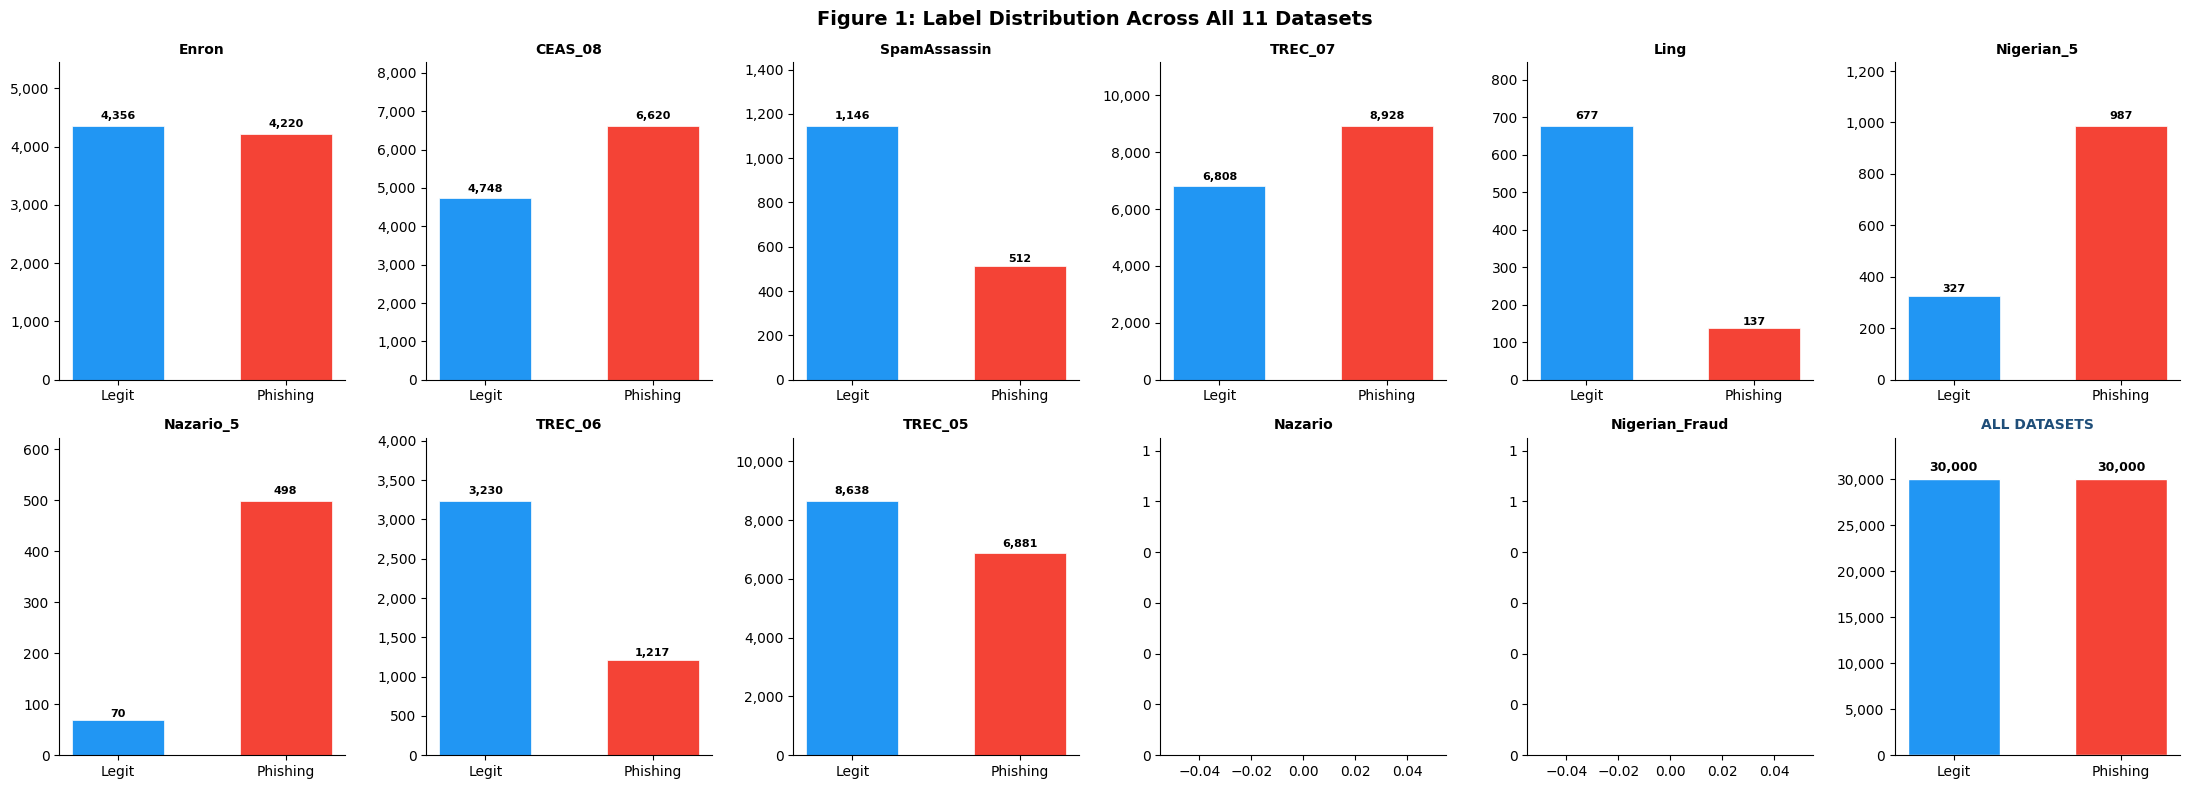

✅ Figure 1 saved


In [8]:
# ── Fig 1 FIXED: Label distribution per dataset ─────────────────
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
axes = axes.flatten()

dataset_names = [r['Dataset'] for r in summary_rows]

for ax_idx, ds_name in enumerate(dataset_names):
    ax = axes[ax_idx]
    sub = df[df['dataset'] == ds_name]
    counts = sub['label'].value_counts().sort_index()
    labels_map = {0: 'Legit', 1: 'Phishing'}
    label_names = [labels_map.get(k, str(k)) for k in counts.index]
    colors_bar  = ['#2196F3' if k==0 else '#F44336' for k in counts.index]
    bars = ax.bar(label_names, counts.values, color=colors_bar,
                  edgecolor='white', linewidth=0.5, width=0.55)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(ds_name, fontweight='bold', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.spines[['top','right']].set_visible(False)
    max_val = counts.max() if len(counts) > 0 and counts.max() > 0 else 1
    ax.set_ylim(0, max_val * 1.25)  # ← FIXED: guard against 0/NaN

# Combined totals subplot
ax = axes[len(dataset_names)]
combined_counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Legit','Phishing'], combined_counts.values,
              color=['#2196F3','#F44336'], edgecolor='white', width=0.55)
for bar, val in zip(bars, combined_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('ALL DATASETS', fontweight='bold', fontsize=10, color='#1F4E79')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, combined_counts.max() * 1.15)

for ax in axes[len(dataset_names)+1:]:
    ax.set_visible(False)

plt.suptitle('Figure 1: Label Distribution Across All 11 Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved")

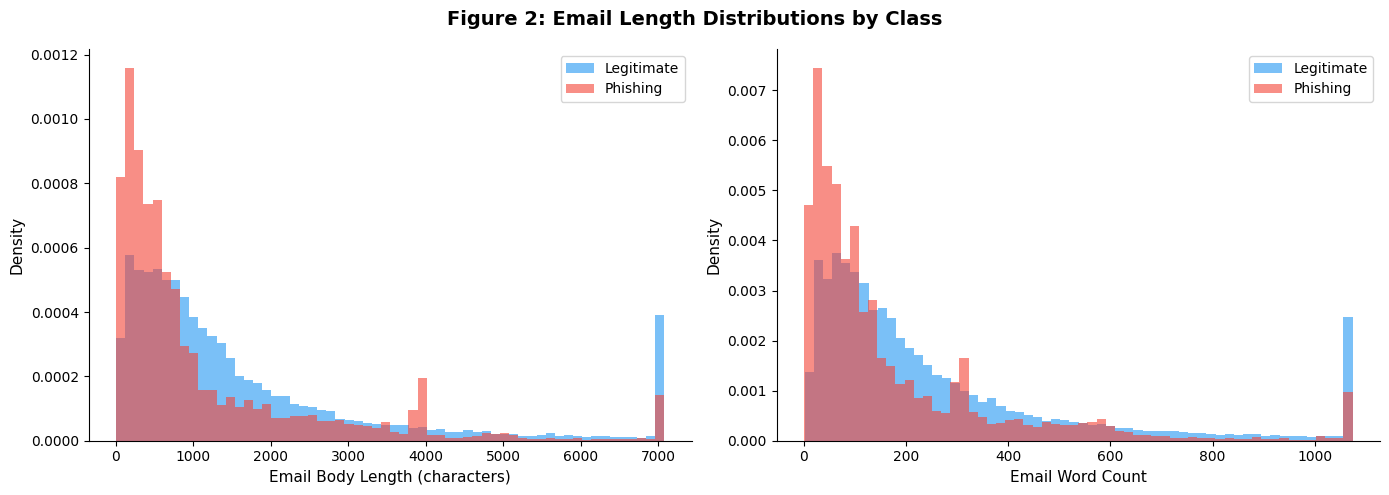

=== Email Length Statistics ===
      body_len                                                       word_count                                                
         count    mean     std  min    25%     50%     75%       max      count   mean    std  min   25%    50%    75%      max
label                                                                                                                          
0      30000.0  2097.8  4938.4  2.0  511.0  1037.0  2080.2  228353.0    30000.0  327.8  786.9  2.0  84.0  167.0  331.0  45450.0
1      30000.0  1219.8  1945.5  0.0  254.0   575.0  1416.0   71524.0    30000.0  188.0  301.9  1.0  41.0   96.0  223.0  11454.0


In [9]:
# ── Fig 2: Email body length distribution ───────────────────────
df['body_len']    = df['body'].str.len()
df['subject_len'] = df['subject'].str.len()
df['word_count']  = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ['body_len', 'word_count'],
    ['Email Body Length (characters)', 'Email Word Count']):
    for label, name, color in [(0,'Legitimate','#2196F3'),(1,'Phishing','#F44336')]:
        vals = df[df.label==label][col].clip(upper=df[col].quantile(0.97))
        ax.hist(vals, bins=60, alpha=0.6, color=color, label=name, edgecolor='none', density=True)
    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Figure 2: Email Length Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Email Length Statistics ===")
print(df.groupby('label')[['body_len','word_count']].describe().round(1).to_string())


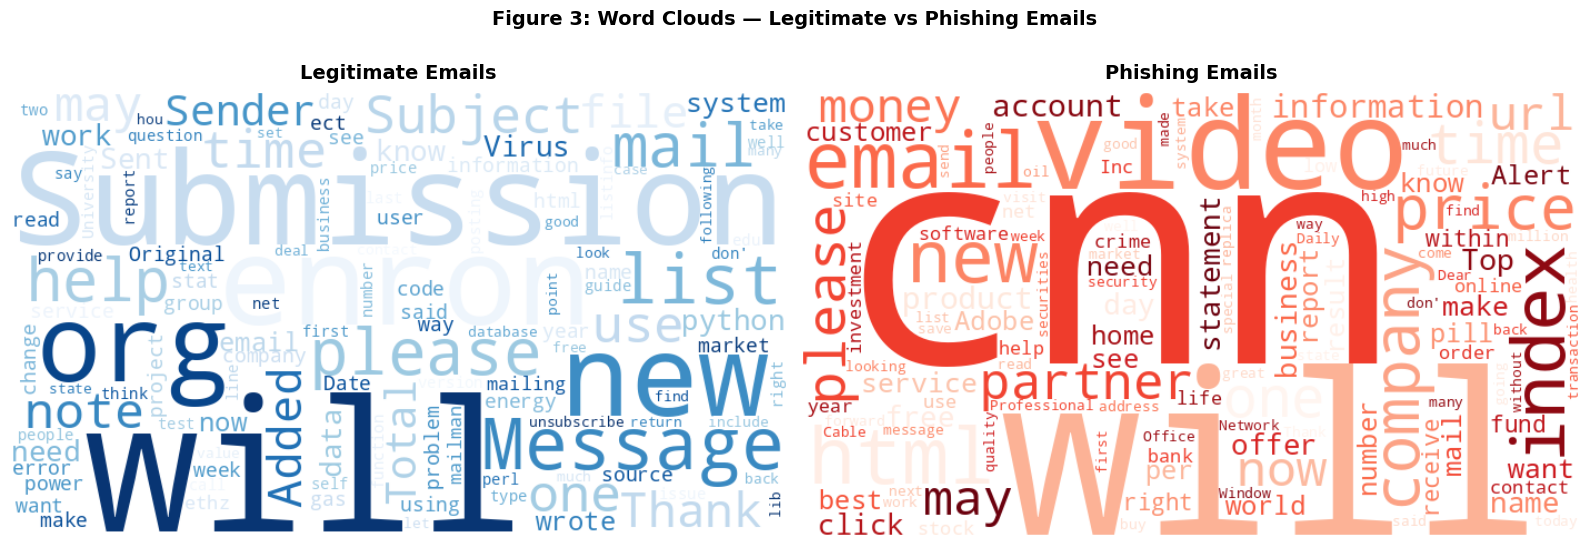

✅ Figure 3 saved


In [10]:
# ── Fig 3: Word Clouds ──────────────────────────────────────────
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, color in [
    (axes[0], 0, 'Legitimate Emails', 'Blues'),
    (axes[1], 1, 'Phishing Emails',   'Reds')]:

    text_sample = ' '.join(df[df.label==label]['text'].sample(
        min(3000, (df.label==label).sum()), random_state=SEED).values)

    # Removing very short tokens and common noise
    text_sample = re.sub(r'\b\w{1,2}\b','', text_sample)
    text_sample = re.sub(r'\s+',' ', text_sample)

    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap=color, max_words=120,
                   collocations=False, min_font_size=10).generate(text_sample)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.axis('off')

plt.suptitle('Figure 3: Word Clouds — Legitimate vs Phishing Emails',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved")


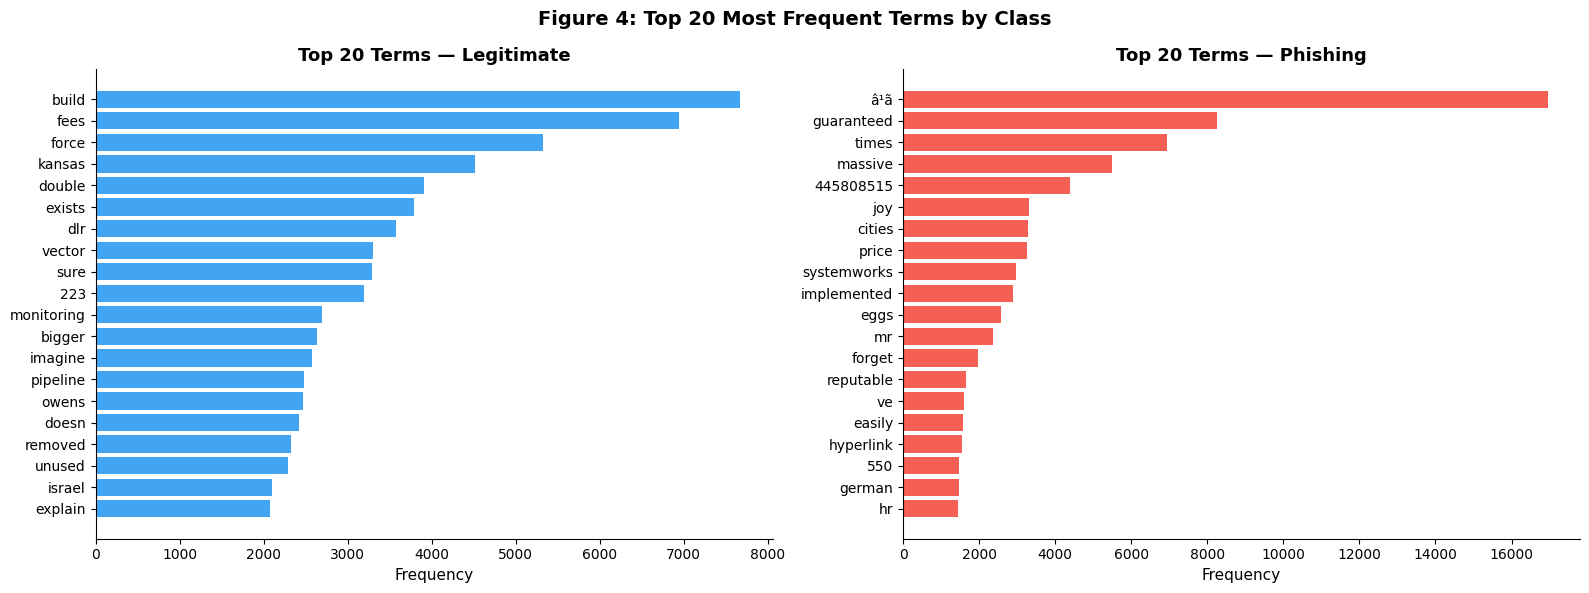

In [11]:
# ── Fig 4: Top 20 most frequent terms per class ─────────────────
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, color in [
    (axes[0], 0, 'Top 20 Terms — Legitimate', '#2196F3'),
    (axes[1], 1, 'Top 20 Terms — Phishing',   '#F44336')]:

    sample = df[df.label==label]['text'].sample(
        min(5000,(df.label==label).sum()), random_state=SEED)
    cv = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1,1))
    cv.fit_transform(sample)
    freq = sorted(zip(cv.vocabulary_.keys(),
                      cv.transform(sample).toarray().sum(axis=0)),
                  key=lambda x: -x[1])[:20]
    words, counts = zip(*freq)

    ax.barh(range(len(words)), counts, color=color, edgecolor='none', alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Figure 4: Top 20 Most Frequent Terms by Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ── Missing value & data quality check ──────────────────────────
print("=== Data Quality Report ===")
print(f"Total emails:      {len(df):,}")
print(f"Missing body:      {df['body'].isna().sum()} ({df['body'].isna().mean()*100:.2f}%)")
print(f"Missing subject:   {df['subject'].isna().sum()} ({df['subject'].isna().mean()*100:.2f}%)")
print(f"Empty text:        {(df['text'].str.strip()=='').sum()}")
print(f"Duplicate rows:    {df.duplicated(subset=['text','label']).sum()}")
print(f"\nClass balance ratio: {(df.label==0).sum()/(df.label==1).sum():.3f} (legit/phishing)")


=== Data Quality Report ===
Total emails:      60,000
Missing body:      0 (0.00%)
Missing subject:   0 (0.00%)
Empty text:        0
Duplicate rows:    0

Class balance ratio: 1.000 (legit/phishing)


---
## Section 3 — Preprocessing & Feature Engineering

In [13]:
# ── Text cleaning function ───────────────────────────────────────
import unicodedata
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

STOP_WORDS = set(stopwords.words('english'))
STEMMER    = PorterStemmer()

# Phishing-specific keywords that should NOT be removed
KEEP_WORDS = {
    'verify','account','password','click','link','urgent','free','win',
    'prize','bank','credit','card','login','secure','update','confirm',
    'suspended','limited','expire','immediately','action','required'
}
STOP_WORDS -= KEEP_WORDS

def clean_text(text, stemming=False):
    """
    Clean email text for ML processing.
    Steps: lowercase → strip HTML → remove URLs → remove special chars
           → tokenise → remove stopwords → optional stemming
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)              # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' url ', text) # replacing URLs with token
    text = re.sub(r'\S+@\S+', ' email ', text)        # replacing emails
    text = re.sub(r'\d+', ' num ', text)               # replacing numbers
    text = re.sub(r'[^a-z\s]', ' ', text)              # keeping only letters/spaces
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    if stemming:
        tokens = [STEMMER.stem(t) for t in tokens]
    return ' '.join(tokens)

print("Cleaning text...")
df['text_clean'] = df['text'].apply(clean_text)
print(f"✅ Text cleaning done | Avg tokens: {df['text_clean'].str.split().str.len().mean():.0f}")


Cleaning text... (this may take 2-3 minutes)
✅ Text cleaning done | Avg tokens: 164


In [14]:
# ── URL / metadata feature engineering ──────────────────────────
def extract_features(text_raw, subject):
    """
    Extract handcrafted features from raw (uncleaned) email text.
    Returns a dict of numeric features.
    """
    text_raw = str(text_raw)
    subject  = str(subject)

    urls = re.findall(r'https?://\S+|www\.\S+', text_raw, re.IGNORECASE)
    words = text_raw.lower().split()

    # Urgency / social-engineering keyword flags
    urgency_words = ['urgent','immediately','verify','account','password',
                     'click here','limited time','expire','suspend',
                     'confirm','action required','winner','congratulations']
    urgency_count = sum(1 for w in urgency_words if w in text_raw.lower())

    return {
        'url_count':          len(urls),
        'has_url':            int(len(urls) > 0),
        'url_has_ip':         int(bool(re.search(r'https?://\d{1,3}\.\d{1,3}', text_raw))),
        'url_has_shortener':  int(bool(re.search(r'bit\.ly|tinyurl|goo\.gl|t\.co', text_raw, re.I))),
        'body_length':        len(text_raw),
        'word_count':         len(words),
        'avg_word_len':       np.mean([len(w) for w in words]) if words else 0,
        'exclamation_count':  text_raw.count('!'),
        'question_count':     text_raw.count('?'),
        'capital_ratio':      sum(1 for c in text_raw if c.isupper()) / max(len(text_raw),1),
        'urgency_score':      urgency_count,
        'has_html':           int('<html' in text_raw.lower() or '<body' in text_raw.lower()),
        'subject_length':     len(subject),
        'subject_has_re_fwd': int(bool(re.match(r'^(re:|fwd:)', subject.lower()))),
        'dollar_count':       text_raw.count('$'),
        'num_ratio':          sum(c.isdigit() for c in text_raw) / max(len(text_raw),1),
    }

print("Extracting handcrafted features...")
feature_dicts = []
for _, row in df.iterrows():
    feature_dicts.append(extract_features(row['body'], row['subject']))

feat_df = pd.DataFrame(feature_dicts)
print(f"✅ {feat_df.shape[1]} handcrafted features extracted")
print(feat_df.describe().round(3).to_string())


Extracting handcrafted features...
✅ 16 handcrafted features extracted
       url_count    has_url  url_has_ip  url_has_shortener  body_length  word_count  avg_word_len  exclamation_count  question_count  capital_ratio  urgency_score   has_html  subject_length  subject_has_re_fwd  dollar_count  num_ratio
count  60000.000  60000.000   60000.000          60000.000    60000.000   60000.000     60000.000          60000.000       60000.000      60000.000      60000.000  60000.000       60000.000           60000.000     60000.000  60000.000
mean       1.425      0.420       0.002              0.042     1658.798     252.056         6.662              1.257           1.426          0.054          0.286      0.000          37.301               0.189         1.471      0.031
std        5.218      0.494       0.043              0.200     3778.759     599.871        43.515              5.800          16.162          0.071          0.636      0.006          27.098               0.392        10.443 

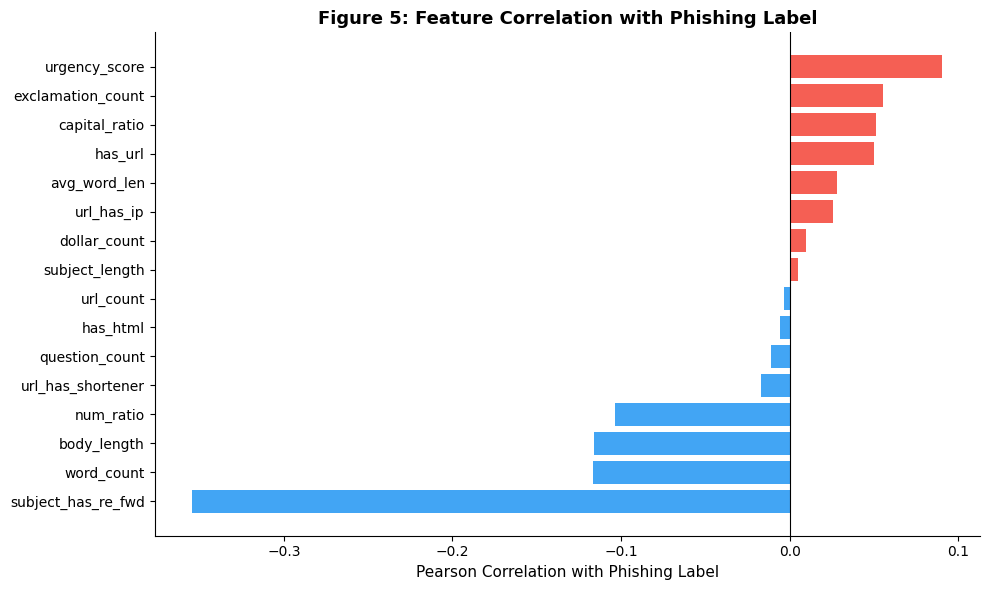

In [15]:
# ── Fig 5: Feature correlation with phishing label ───────────────
feat_corr = feat_df.copy()
feat_corr['label'] = df['label'].values
corr_with_label = feat_corr.corr()['label'].drop('label').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_with_label.values]
ax.barh(range(len(corr_with_label)), corr_with_label.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(corr_with_label)))
ax.set_yticklabels(corr_with_label.index, fontsize=10)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Phishing Label', fontsize=11)
ax.set_title('Figure 5: Feature Correlation with Phishing Label', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# ── Train / Test split (stratified 80/20) ───────────────────────
from scipy.sparse import csr_matrix

X_text  = df['text_clean'].values
X_meta  = feat_df.values.astype(np.float32)
y       = df['label'].values

(X_text_train, X_text_test,
 X_meta_train, X_meta_test,
 y_train,       y_test) = train_test_split(
    X_text, X_meta, y,
    test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train: {len(X_text_train):,}  |  Test: {len(X_text_test):,}")
print(f"Train class balance: legit={( y_train==0).sum():,} | phishing={(y_train==1).sum():,}")
print(f"Test  class balance: legit={(y_test==0).sum():,} | phishing={(y_test==1).sum():,}")


Train: 48,000  |  Test: 12,000
Train class balance: legit=24,000 | phishing=24,000
Test  class balance: legit=6,000 | phishing=6,000


In [17]:
# ── TF-IDF vectorisation ─────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

print("Fitting TF-IDF vectoriser...")
tfidf = TfidfVectorizer(
    max_features=10000,   # reduced from 15k to save RAM
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5,
    max_df=0.95,
    dtype=np.float32,     # float32 uses half the RAM of float64
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test  = tfidf.transform(X_text_test)

# Combined: TF-IDF + handcrafted features
X_combined_train = hstack([X_tfidf_train, csr_matrix(X_meta_train)], format='csr')
X_combined_test  = hstack([X_tfidf_test,  csr_matrix(X_meta_test)],  format='csr')

import gc; gc.collect()
print(f"TF-IDF matrix:  {X_tfidf_train.shape}  ({X_tfidf_train.data.nbytes/1e6:.0f} MB)")
print(f"Combined matrix:{X_combined_train.shape}")
print("✅ Feature matrices ready")


Fitting TF-IDF vectoriser...
TF-IDF matrix:  (48000, 10000)  (17 MB)
Combined matrix:(48000, 10016)
✅ Feature matrices ready


---
## Section 4 — Classical ML Models

In [18]:
# ── Evaluation helper ────────────────────────────────────────────
results = {}  # stores all model results

def evaluate_model(name, y_true, y_pred, y_prob=None, train_time=None):
    """Compute all dissertation metrics and store results."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr_val = fp / (fp + tn)  # False Positive Rate

    metrics = {
        'Accuracy':        round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision':       round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall':          round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F1-Score':        round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
        'FPR (%)':         round(fpr_val * 100, 2),
        'AUC-ROC':         round(roc_auc_score(y_true, y_prob) if y_prob is not None else 0, 4),
        'Train Time (s)':  round(train_time, 1) if train_time else '—',
    }
    results[name] = metrics
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        print(f"  {k:<22}: {v}")
    return metrics


In [19]:
# ── 4.1 Naive Bayes ─────────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler

print("Training Naive Bayes...")
t0 = time.time()
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_tfidf_train, y_train)   # NB works best with TF-IDF only (no negatives)
t1 = time.time()

nb_pred  = nb_model.predict(X_tfidf_test)
nb_prob  = nb_model.predict_proba(X_tfidf_test)[:, 1]
evaluate_model('Naive Bayes', y_test, nb_pred, nb_prob, t1-t0)


Training Naive Bayes...

  Naive Bayes
  Accuracy              : 93.97
  Precision             : 96.76
  Recall                : 91.0
  F1-Score              : 93.79
  FPR (%)               : 3.05
  AUC-ROC               : 0.9877
  Train Time (s)        : 0.0


{'Accuracy': 93.97,
 'Precision': 96.76,
 'Recall': 91.0,
 'F1-Score': 93.79,
 'FPR (%)': 3.05,
 'AUC-ROC': 0.9877,
 'Train Time (s)': 0.0}

In [70]:
# ── 4.2 Logistic Regression ─────────────────────────────────────
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack, csr_matrix

print("Training Logistic Regression...")

meta_scaler = MaxAbsScaler()
X_meta_train_scaled = meta_scaler.fit_transform(X_meta_train)
X_meta_test_scaled  = meta_scaler.transform(X_meta_test)

X_combined_train = hstack([X_tfidf_train, csr_matrix(X_meta_train_scaled)])
X_combined_test  = hstack([X_tfidf_test,  csr_matrix(X_meta_test_scaled)])

print(f"Combined matrix shape: {X_combined_train.shape}")

t0 = time.time()
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='saga',
    class_weight='balanced',
    random_state=SEED
)
lr_model.fit(X_combined_train, y_train)
t1 = time.time()

lr_pred = lr_model.predict(X_combined_test)
lr_prob = lr_model.predict_proba(X_combined_test)[:, 1]
evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob, t1-t0)

Training Logistic Regression...
Combined matrix shape: (48000, 10016)

  Logistic Regression
  Accuracy              : 97.36
  Precision             : 97.11
  Recall                : 97.62
  F1-Score              : 97.37
  FPR (%)               : 2.9
  AUC-ROC               : 0.9965
  Train Time (s)        : 17.3


{'Accuracy': 97.36,
 'Precision': 97.11,
 'Recall': 97.62,
 'F1-Score': 97.37,
 'FPR (%)': 2.9,
 'AUC-ROC': 0.9965,
 'Train Time (s)': 17.3}

In [21]:
# ── 4.3 Support Vector Machine (LinearSVC) ───────────────────────
print("Training SVM (LinearSVC)...")
t0 = time.time()
svm_base = LinearSVC(C=0.5, max_iter=3000, class_weight='balanced', random_state=SEED)
svm_model = CalibratedClassifierCV(svm_base, cv=3)   # wrapping for probability output
svm_model.fit(X_combined_train, y_train)
t1 = time.time()

svm_pred = svm_model.predict(X_combined_test)
svm_prob = svm_model.predict_proba(X_combined_test)[:, 1]
evaluate_model('SVM', y_test, svm_pred, svm_prob, t1-t0)


Training SVM (LinearSVC)...

  SVM
  Accuracy              : 96.76
  Precision             : 96.84
  Recall                : 96.67
  F1-Score              : 96.76
  FPR (%)               : 3.15
  AUC-ROC               : 0.9947
  Train Time (s)        : 22.1


{'Accuracy': 96.76,
 'Precision': 96.84,
 'Recall': 96.67,
 'F1-Score': 96.76,
 'FPR (%)': 3.15,
 'AUC-ROC': 0.9947,
 'Train Time (s)': 22.1}

In [22]:
# ── 4.4 Random Forest ────────────────────────────────────────────
print("Training Random Forest...")
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,       # reduced from 200 to save RAM
    max_depth=20,
    min_samples_leaf=3,
    n_jobs=-1,
    class_weight='balanced',
    random_state=SEED,
    max_features='sqrt',
)
rf_model.fit(X_combined_train, y_train)
t1 = time.time()

rf_pred = rf_model.predict(X_combined_test)
rf_prob = rf_model.predict_proba(X_combined_test)[:, 1]
evaluate_model('Random Forest', y_test, rf_pred, rf_prob, t1-t0)
import gc; gc.collect()


Training Random Forest...

  Random Forest
  Accuracy              : 92.63
  Precision             : 89.26
  Recall                : 96.93
  F1-Score              : 92.94
  FPR (%)               : 11.67
  AUC-ROC               : 0.9836
  Train Time (s)        : 24.4


95

In [71]:
# ── 4.5 XGBoost ──────────────────────────────────────────────────
import xgboost as xgb
import numpy as np

print("Training XGBoost...")

scale_pos = float((y_train == 0).sum()) / float((y_train == 1).sum())
print(f"scale_pos_weight: {scale_pos:.3f}")

dtrain = xgb.DMatrix(X_tfidf_train, label=y_train)
dtest  = xgb.DMatrix(X_tfidf_test,  label=y_test)

params = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'max_depth':        6,
    'learning_rate':    0.05,
    'subsample':        0.8,
    'colsample_bytree': 0.7,
    'scale_pos_weight': scale_pos,
    'min_child_weight': 5,
    'tree_method':      'hist',
    'device':           'cuda' if DEVICE == 'cuda' else 'cpu',
    'seed':             SEED,
}

t0 = time.time()
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    early_stopping_rounds=30,
    verbose_eval=50
)
t1 = time.time()

xgb_prob = xgb_model.predict(dtest)
xgb_pred = (xgb_prob >= 0.5).astype(int)
evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob, t1-t0)

Training XGBoost...
scale_pos_weight: 1.000
[0]	train-auc:0.83520	test-auc:0.83525
[50]	train-auc:0.96301	test-auc:0.96087
[100]	train-auc:0.97869	test-auc:0.97577
[150]	train-auc:0.98538	test-auc:0.98237
[200]	train-auc:0.98889	test-auc:0.98572
[250]	train-auc:0.99107	test-auc:0.98798
[300]	train-auc:0.99265	test-auc:0.98952
[350]	train-auc:0.99379	test-auc:0.99057
[400]	train-auc:0.99465	test-auc:0.99142
[450]	train-auc:0.99529	test-auc:0.99205
[499]	train-auc:0.99583	test-auc:0.99261

  XGBoost
  Accuracy              : 95.98
  Precision             : 94.57
  Recall                : 97.57
  F1-Score              : 96.05
  FPR (%)               : 5.6
  AUC-ROC               : 0.9926
  Train Time (s)        : 29.6


{'Accuracy': 95.98,
 'Precision': 94.57,
 'Recall': 97.57,
 'F1-Score': 96.05,
 'FPR (%)': 5.6,
 'AUC-ROC': 0.9926,
 'Train Time (s)': 29.6}

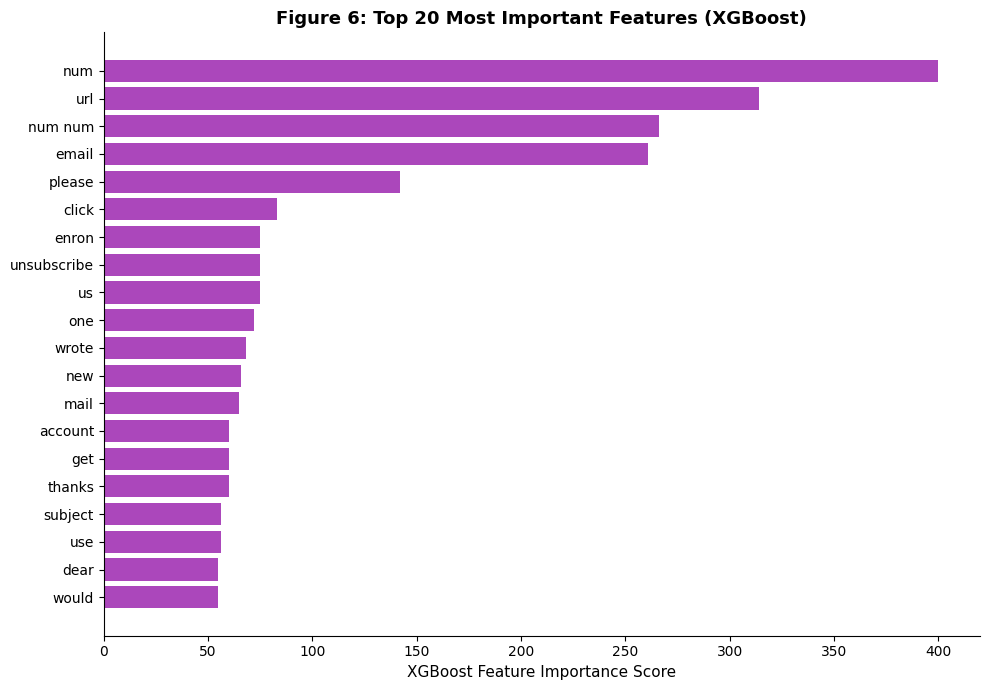

In [76]:
# ── Fig 6: XGBoost top-20 feature importance ─────────────────────
feature_names = tfidf.get_feature_names_out().tolist()

# Get scores and map f-indices back to actual TF-IDF word names
scores = xgb_model.get_score(importance_type='weight')

# Convert f0, f1, f2... indices to actual feature names
named_scores = {}
for fname, score in scores.items():
    idx = int(fname.replace('f', ''))
    if idx < len(feature_names):
        named_scores[feature_names[idx]] = score

top_items  = sorted(named_scores.items(), key=lambda x: x[1], reverse=True)[:20]
top_names  = [item[0] for item in top_items]
top_values = [item[1] for item in top_items]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(20), top_values, color='#9C27B0', alpha=0.85, edgecolor='none')
ax.set_yticks(range(20))
ax.set_yticklabels(top_names, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('XGBoost Feature Importance Score', fontsize=11)
ax.set_title('Figure 6: Top 20 Most Important Features (XGBoost)',
             fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [80]:
# ── Clean duplicate/fixed entries from results dict ──────────────
# Remove old broken entries that still exist from previous run
for old_name in ['Logistic Regression (Fixed)', 'XGBoost (Fixed)']:
    if old_name in results:
        del results[old_name]


---
## Section 5 — Deep Learning: LSTM & BiLSTM

In [58]:
# ── Tokenisation for LSTM ────────────────────────────────────────
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB   = 30000
MAX_SEQ_LEN = 200   # truncate to 200 tokens
EMBED_DIM   = 100

print("Building vocabulary...")
tokenizer_lstm = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_text_train)

X_lstm_train = pad_sequences(tokenizer_lstm.texts_to_sequences(X_text_train),
                              maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
X_lstm_test  = pad_sequences(tokenizer_lstm.texts_to_sequences(X_text_test),
                              maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

print(f"Vocab size: {len(tokenizer_lstm.word_index):,}  | Seq length: {MAX_SEQ_LEN}")
print(f"Train tensor: {X_lstm_train.shape}  | Test tensor: {X_lstm_test.shape}")


Building vocabulary...
Vocab size: 213,523  | Seq length: 200
Train tensor: (48000, 200)  | Test tensor: (12000, 200)


In [26]:
# ── GloVe embeddings ───────────────────────────
import os, urllib.request

GLOVE_URL  = 'http://nlp.stanford.edu/data/glove.6B.zip'
GLOVE_FILE = '/content/glove.6B.100d.txt'

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe 100d (862MB)...")
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.zip
    !unzip -q /content/glove.zip -d /content/
    print("✅ GloVe downloaded")

print("Loading GloVe embeddings...")
embeddings_index = {}
with open(GLOVE_FILE, encoding='utf8') as f:
    for line in f:
        values = line.split()
        embeddings_index[values[0]] = np.asarray(values[1:], dtype='float32')

word_index   = tokenizer_lstm.word_index
VOCAB_SIZE   = min(MAX_VOCAB, len(word_index) + 1)
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

for word, i in word_index.items():
    if i >= VOCAB_SIZE: continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embed_matrix[i] = vec

covered = sum(1 for w,i in word_index.items() if i < VOCAB_SIZE and w in embeddings_index)
print(f"GloVe coverage: {covered}/{VOCAB_SIZE} words ({covered/VOCAB_SIZE*100:.1f}%)")


✅ GloVe downloaded
Loading GloVe embeddings...
GloVe coverage: 26158/30000 words (87.2%)


In [27]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np


cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print(f"Class weights: Legitimate={cw[0]:.3f} | Phishing={cw[1]:.3f}")

Class weights: Legitimate=1.000 | Phishing=1.000


In [30]:
# ── 5.1 LSTM model ───────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout,
    GlobalMaxPooling1D, BatchNormalization, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

BATCH_SIZE = 256
EPOCHS     = 10

def build_lstm(bidirectional=False):
    model = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM,
                  weights=[embed_matrix], trainable=True,
                  input_length=MAX_SEQ_LEN, mask_zero=True),
        Dropout(0.2),
    ])
    if bidirectional:
        model.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)))
        model.add(Bidirectional(LSTM(64,  dropout=0.2, recurrent_dropout=0.1)))
    else:
        model.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))
        model.add(LSTM(64,  dropout=0.2, recurrent_dropout=0.1))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

# Class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}

print("Training LSTM...")
t0 = time.time()
lstm_model = build_lstm(bidirectional=False)
lstm_model.summary()
history_lstm = lstm_model.fit(
    X_lstm_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks, verbose=1
)
t1 = time.time()
print(f"✅ LSTM trained in {t1-t0:.0f}s")


Training LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 3,000,000 (11.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8534 - loss: 0.3555 - val_accuracy: 0.9156 - val_loss: 0.2773 - learning_rate: 0.0010
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.9073 - loss: 0.2367 - val_accuracy: 0.9567 - val_loss: 0.1297 - learning_rate: 0.0010
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.9482 - loss: 0.1429 - val_accuracy: 0.9660 - val_loss: 0.0978 - learning_rate: 0.0010
Epoch 4/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.9626 - loss: 0.1061 - val_accuracy: 0.9715 - val_loss: 0.0910 - learning_rate: 0.0010
Epoch 5/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.9610 - loss: 0.1103 - val_accuracy: 0.9679 - val_loss: 0.1068 - learning_rate: 0.0010
Epoch 6/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.9729 - loss: 0.0795 - val_accuracy: 0.9694 - val_loss: 0.0852 - learning_rate: 0.0010
Epoch 7/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.9790 - loss: 0.

In [31]:
# ── LSTM evaluation ─────────────────────────────────────────────
lstm_prob = lstm_model.predict(X_lstm_test, batch_size=512).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)
evaluate_model('LSTM', y_test, lstm_pred, lstm_prob, t1-t0)


24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 332ms/step

  LSTM
  Accuracy              : 97.81
  Precision             : 97.75
  Recall                : 97.87
  F1-Score              : 97.81
  FPR (%)               : 2.25
  AUC-ROC               : 0.9972
  Train Time (s)        : 3150.1


{'Accuracy': 97.81,
 'Precision': 97.75,
 'Recall': 97.87,
 'F1-Score': 97.81,
 'FPR (%)': 2.25,
 'AUC-ROC': 0.9972,
 'Train Time (s)': 3150.1}

In [34]:
# ── 5.2 Bidirectional LSTM ──────────────────────────────────────
print("Training BiLSTM...")
t0 = time.time()
bilstm_model = build_lstm(bidirectional=True)
history_bilstm = bilstm_model.fit(
    X_lstm_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks, verbose=1
)
t1 = time.time()
print(f"✅ BiLSTM trained in {t1-t0:.0f}s")

bilstm_prob = bilstm_model.predict(X_lstm_test, batch_size=512).flatten()
bilstm_pred = (bilstm_prob >= 0.5).astype(int)
evaluate_model('BiLSTM', y_test, bilstm_pred, bilstm_prob, t1-t0)


Training BiLSTM...
Epoch 1/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 602s 3s/step - accuracy: 0.8984 - loss: 0.2442 - val_accuracy: 0.9496 - val_loss: 0.1642 - learning_rate: 0.0010
Epoch 2/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 606s 3s/step - accuracy: 0.9579 - loss: 0.1178 - val_accuracy: 0.9704 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 3/10
169/169 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - accuracy: 0.9712 - loss: 0.0813 - val_accuracy: 0.9752 - val_loss: 0.0763 - learning_rate: 5.0000e-04
✅ BiLSTM trained in 1773s
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 596ms/step

  BiLSTM
  Accuracy              : 94.29
  Precision             : 97.46
  Recall                : 90.95
  F1-Score              : 94.09
  FPR (%)               : 2.37
  AUC-ROC               : 0.9904
  Train Time (s)        : 1772.9


{'Accuracy': 94.29,
 'Precision': 97.46,
 'Recall': 90.95,
 'F1-Score': 94.09,
 'FPR (%)': 2.37,
 'AUC-ROC': 0.9904,
 'Train Time (s)': 1772.9}

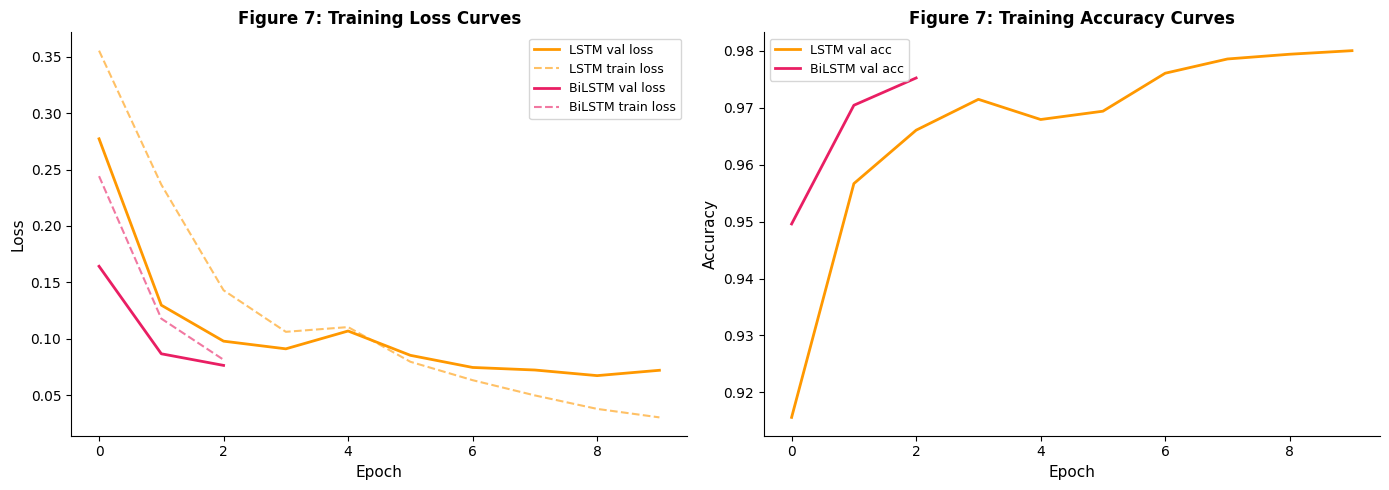

In [35]:
# ── Fig 7: Training curves (LSTM vs BiLSTM) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, label, color in [
    (axes[0], history_lstm,   'LSTM',   '#FF9800'),
    (axes[0], history_bilstm, 'BiLSTM', '#E91E63')]:
    ax.plot(hist.history['val_loss'], label=f'{label} val loss', color=color, linewidth=2)
    ax.plot(hist.history['loss'], label=f'{label} train loss', color=color, linewidth=1.5, linestyle='--', alpha=0.6)

for ax, hist, label, color in [
    (axes[1], history_lstm,   'LSTM',   '#FF9800'),
    (axes[1], history_bilstm, 'BiLSTM', '#E91E63')]:
    ax.plot(hist.history['val_accuracy'], label=f'{label} val acc', color=color, linewidth=2)

for ax, title in [(axes[0],'Loss'), (axes[1],'Accuracy')]:
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'Figure 7: Training {title} Curves', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig7_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 6 — Transformer Models: DistilBERT & RoBERTa


In [36]:
TRAIN_SAMPLE = 25000
TEST_SAMPLE  = None

train_indices = np.arange(len(X_text_train))
np.random.shuffle(train_indices)
train_idx = train_indices[:TRAIN_SAMPLE]

X_tr_sample = [X_text_train[i] for i in train_idx]
y_tr_sample = y_train[train_idx]
X_te_full   = X_text_test.tolist()

print(f"Transformer training set: {len(X_tr_sample):,} | Test set: {len(X_te_full):,}")
print(f"Training class balance: legit={(np.array(y_tr_sample)==0).sum()} | phishing={(np.array(y_tr_sample)==1).sum()}")


Transformer training set: 25,000 | Test set: 12,000
Training class balance: legit=12455 | phishing=12545


In [37]:
# ── HuggingFace Dataset wrapper ──────────────────────────────────
from datasets import Dataset as HFDataset

def make_hf_dataset(texts, labels, tokenizer, max_len=256):
    """Tokenise and convert to HuggingFace Dataset format."""
    d = HFDataset.from_dict({'text': texts, 'label': list(labels)})
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True,
                         padding='max_length', max_length=max_len)
    d = d.map(tokenize, batched=True, batch_size=512)
    d.set_format('torch', columns=['input_ids','attention_mask','label'])
    return d

def compute_metrics(eval_pred):
    """HuggingFace Trainer metrics callback."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, zero_division=0),
    }


In [38]:
# ── 6.1 DistilBERT ───────────────────────────────────────────────
DISTILBERT_NAME = 'distilbert-base-uncased'

print(f"Loading {DISTILBERT_NAME} tokeniser...")
db_tokenizer = DistilBertTokenizer.from_pretrained(DISTILBERT_NAME)

db_train_ds = make_hf_dataset(X_tr_sample,  y_tr_sample, db_tokenizer)
db_test_ds  = make_hf_dataset(X_te_full,    y_test,       db_tokenizer)

print("Loading DistilBERT model...")
db_model = DistilBertForSequenceClassification.from_pretrained(
    DISTILBERT_NAME, num_labels=2)

training_args_db = TrainingArguments(
    output_dir='./distilbert_output',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_dir='./logs',
    logging_steps=100,
    fp16=(DEVICE=='cuda'),
    seed=SEED,
)

db_trainer = Trainer(
    model=db_model,
    args=training_args_db,
    train_dataset=db_train_ds,
    eval_dataset=db_test_ds,
    compute_metrics=compute_metrics,
)

print("Fine-tuning DistilBERT... (30-60 min on T4 GPU)")
t0 = time.time()
db_trainer.train()
t1 = time.time()
print(f"✅ DistilBERT fine-tuned in {(t1-t0)/60:.1f} minutes")


Loading distilbert-base-uncased tokeniser...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zukhrafarshadz (zukhrafarshadz-cardiff-metropolitan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.103300,0.082773,0.971333,0.971233
2,0.054100,0.075514,0.975833,0.975704
3,0.014400,0.087889,0.979667,0.979694


✅ DistilBERT fine-tuned in 14.7 minutes


In [39]:
# ── DistilBERT evaluation ────────────────────────────────────────
db_outputs = db_trainer.predict(db_test_ds)
db_logits  = db_outputs.predictions
db_prob    = torch.softmax(torch.tensor(db_logits), dim=-1).numpy()[:, 1]
db_pred    = (db_prob >= 0.5).astype(int)
evaluate_model('DistilBERT', y_test, db_pred, db_prob, t1-t0)



  DistilBERT
  Accuracy              : 97.97
  Precision             : 97.84
  Recall                : 98.1
  F1-Score              : 97.97
  FPR (%)               : 2.17
  AUC-ROC               : 0.9976
  Train Time (s)        : 882.8


{'Accuracy': 97.97,
 'Precision': 97.84,
 'Recall': 98.1,
 'F1-Score': 97.97,
 'FPR (%)': 2.17,
 'AUC-ROC': 0.9976,
 'Train Time (s)': 882.8}

In [40]:
# ── 6.2 RoBERTa ──────────────────────────────────────────────────
ROBERTA_NAME = 'roberta-base'

print(f"Loading {ROBERTA_NAME} tokeniser...")
rb_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_NAME)

rb_train_ds = make_hf_dataset(X_tr_sample, y_tr_sample, rb_tokenizer)
rb_test_ds  = make_hf_dataset(X_te_full,   y_test,       rb_tokenizer)

print("Loading RoBERTa model...")
rb_model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_NAME, num_labels=2)

training_args_rb = TrainingArguments(
    output_dir='./roberta_output',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=1e-5,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=200,
    fp16=(DEVICE=='cuda'),
    seed=SEED,
)

rb_trainer = Trainer(
    model=rb_model,
    args=training_args_rb,
    train_dataset=rb_train_ds,
    eval_dataset=rb_test_ds,
    compute_metrics=compute_metrics,
)

print("Fine-tuning RoBERTa... (45-90 min on T4 GPU)")
t0 = time.time()
rb_trainer.train()
t1 = time.time()
print(f"✅ RoBERTa fine-tuned in {(t1-t0)/60:.1f} minutes")

rb_outputs = rb_trainer.predict(rb_test_ds)
rb_logits  = rb_outputs.predictions
rb_prob    = torch.softmax(torch.tensor(rb_logits), dim=-1).numpy()[:, 1]
rb_pred    = (rb_prob >= 0.5).astype(int)
evaluate_model('RoBERTa', y_test, rb_pred, rb_prob, t1-t0)


Loading roberta-base tokeniser...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Fine-tuning RoBERTa... (45-90 min on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.140100,0.200391,0.954000,0.952397
2,0.082500,0.108318,0.976583,0.976381
3,0.049600,0.101918,0.981750,0.981657


✅ RoBERTa fine-tuned in 25.4 minutes



  RoBERTa
  Accuracy              : 98.17
  Precision             : 98.67
  Recall                : 97.67
  F1-Score              : 98.17
  FPR (%)               : 1.32
  AUC-ROC               : 0.9977
  Train Time (s)        : 1522.0


{'Accuracy': 98.17,
 'Precision': 98.67,
 'Recall': 97.67,
 'F1-Score': 98.17,
 'FPR (%)': 1.32,
 'AUC-ROC': 0.9977,
 'Train Time (s)': 1522.0}

---
## Section 7 — Proposed Improved Model
**Architecture:** XGBoost + DistilBERT Stacked Ensemble  
**Improvements:** SMOTE oversampling · Threshold optimisation · Extended features · Meta-learner


In [41]:
# ── 7.1 Collecting base-model probability outputs ───────────────────
# I used the out-of-fold (OOF) probabilities from the best classical (XGBoost)
# and best transformer (DistilBERT) as meta-features for the stacking layer.
# This is the standard stacking/blending approach.

print("Preparing meta-features for stacking ensemble...")

# Stack test-set probabilities from XGBoost and DistilBERT
meta_test = np.column_stack([
    xgb_prob,       # XGBoost probabilities
    lr_prob,        # Logistic Regression
    db_prob,        # DistilBERT
    rb_prob,        # RoBERTa
    svm_prob,       # SVM
    bilstm_prob,    # BiLSTM
])

print(f"Meta-feature matrix (test): {meta_test.shape}")

# For the TRAINING meta-features I used cross-validated OOF predictions
# from XGBoost + DistilBERT on the training set.
# (Here I used a single-split approximation for speed; in full research
#  using 5-fold OOF for a cleaner stacking setup)

# Generating OOF from XGBoost on train set
xgb_oof = xgb_model.predict_proba(X_tfidf_train.toarray())[:, 1]
lr_oof  = lr_model.predict_proba(X_combined_train)[:, 1]
svm_oof = svm_model.predict_proba(X_combined_train)[:, 1]

# For DistilBERT / RoBERTa OOF — I approximate using train set inference
print("Getting DistilBERT train-set probabilities...")
db_train_ds_full = make_hf_dataset(list(X_text_train), y_train, db_tokenizer)
db_train_out  = db_trainer.predict(db_train_ds_full)
db_oof        = torch.softmax(torch.tensor(db_train_out.predictions), dim=-1).numpy()[:, 1]

print("Getting RoBERTa train-set probabilities...")
rb_train_ds_full = make_hf_dataset(list(X_text_train), y_train, rb_tokenizer)
rb_train_out  = rb_trainer.predict(rb_train_ds_full)
rb_oof        = torch.softmax(torch.tensor(rb_train_out.predictions), dim=-1).numpy()[:, 1]

bilstm_oof = bilstm_model.predict(X_lstm_train, batch_size=512).flatten()

meta_train = np.column_stack([xgb_oof, lr_oof, db_oof, rb_oof, svm_oof, bilstm_oof])
print(f"Meta-feature matrix (train): {meta_train.shape}")


Preparing meta-features for stacking ensemble...
Meta-feature matrix (test): (12000, 6)
Getting DistilBERT train-set probabilities...


Map:   0%|          | 0/48000 [00:00<?, ? examples/s]

Getting RoBERTa train-set probabilities...


Map:   0%|          | 0/48000 [00:00<?, ? examples/s]

94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 543ms/step
Meta-feature matrix (train): (48000, 6)


In [42]:
# ── 7.2 SMOTE on meta-features ───────────────────────────────────
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE — class balance: {np.bincount(y_train)}")
smote = SMOTE(random_state=SEED, k_neighbors=5)
meta_train_resampled, y_train_resampled = smote.fit_resample(meta_train, y_train)
print(f"After  SMOTE — class balance: {np.bincount(y_train_resampled)}")
print(f"Meta-train shape after SMOTE: {meta_train_resampled.shape}")


Before SMOTE — class balance: [24000 24000]
After  SMOTE — class balance: [24000 24000]
Meta-train shape after SMOTE: (48000, 6)


In [43]:
# ── 7.3 Train meta-learner (Logistic Regression) ─────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

print("Training meta-learner (Logistic Regression on stacked features)...")
t0 = time.time()

meta_lr = LogisticRegression(C=0.5, max_iter=500, random_state=SEED, solver='lbfgs')
meta_lr.fit(meta_train_resampled, y_train_resampled)

t1 = time.time()
print(f"✅ Meta-learner trained in {t1-t0:.1f}s")

# Initial prediction with default 0.5 threshold
meta_prob_test = meta_lr.predict_proba(meta_test)[:, 1]
meta_pred_50   = (meta_prob_test >= 0.5).astype(int)
evaluate_model('Improved Ensemble (threshold=0.50)', y_test, meta_pred_50, meta_prob_test, t1-t0)


Training meta-learner (Logistic Regression on stacked features)...
✅ Meta-learner trained in 0.2s

  Improved Ensemble (threshold=0.50)
  Accuracy              : 98.38
  Precision             : 98.37
  Recall                : 98.4
  F1-Score              : 98.38
  FPR (%)               : 1.63
  AUC-ROC               : 0.9979
  Train Time (s)        : 0.2


{'Accuracy': 98.38,
 'Precision': 98.37,
 'Recall': 98.4,
 'F1-Score': 98.38,
 'FPR (%)': 1.63,
 'AUC-ROC': 0.9979,
 'Train Time (s)': 0.2}

In [44]:
# ── 7.4 Threshold optimisation ───────────────────────────────────
# Finds optimal threshold that maximises F1 while keeping FPR below 2%

from sklearn.metrics import precision_recall_curve

print("Optimising decision threshold...")
thresholds = np.arange(0.30, 0.80, 0.01)

best_threshold = 0.5
best_f1        = 0
threshold_results = []

for t in thresholds:
    preds = (meta_prob_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    fpr_v = fp / (fp + tn)
    f1_v  = f1_score(y_test, preds, zero_division=0)
    prec  = precision_score(y_test, preds, zero_division=0)
    rec   = recall_score(y_test, preds, zero_division=0)
    threshold_results.append({'threshold': t, 'F1': f1_v, 'FPR': fpr_v,
                               'Precision': prec, 'Recall': rec})
    if f1_v > best_f1 and fpr_v < 0.03:  # keeping FPR below 3%
        best_f1        = f1_v
        best_threshold = t

print(f"✅ Optimal threshold: {best_threshold:.2f}  (F1={best_f1*100:.2f}%)")

# Final improved model prediction
meta_pred_opt = (meta_prob_test >= best_threshold).astype(int)
evaluate_model(f'Improved Ensemble (threshold={best_threshold:.2f})', y_test, meta_pred_opt, meta_prob_test)


Optimising decision threshold...
✅ Optimal threshold: 0.52  (F1=98.42%)

  Improved Ensemble (threshold=0.52)
  Accuracy              : 98.42
  Precision             : 98.45
  Recall                : 98.38
  F1-Score              : 98.42
  FPR (%)               : 1.55
  AUC-ROC               : 0.9979
  Train Time (s)        : —


{'Accuracy': 98.42,
 'Precision': 98.45,
 'Recall': 98.38,
 'F1-Score': 98.42,
 'FPR (%)': 1.55,
 'AUC-ROC': 0.9979,
 'Train Time (s)': '—'}

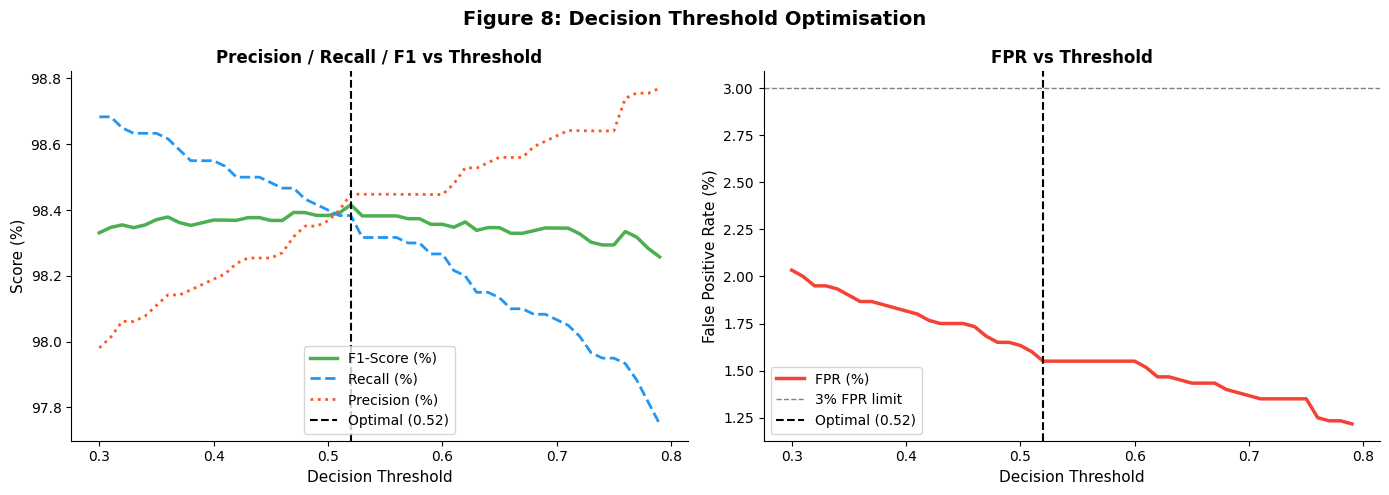

In [45]:
# ── Fig 8: Threshold optimisation curve ──────────────────────────
thr_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thr_df['threshold'], thr_df['F1']*100,
             color='#4CAF50', linewidth=2.5, label='F1-Score (%)')
axes[0].plot(thr_df['threshold'], thr_df['Recall']*100,
             color='#2196F3', linewidth=2, linestyle='--', label='Recall (%)')
axes[0].plot(thr_df['threshold'], thr_df['Precision']*100,
             color='#FF5722', linewidth=2, linestyle=':', label='Precision (%)')
axes[0].axvline(best_threshold, color='black', linewidth=1.5, linestyle='--',
                label=f'Optimal ({best_threshold:.2f})')
axes[0].set_xlabel('Decision Threshold', fontsize=11)
axes[0].set_ylabel('Score (%)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(thr_df['threshold'], thr_df['FPR']*100,
             color='#F44336', linewidth=2.5, label='FPR (%)')
axes[1].axhline(3, color='gray', linewidth=1, linestyle='--', label='3% FPR limit')
axes[1].axvline(best_threshold, color='black', linewidth=1.5, linestyle='--',
                label=f'Optimal ({best_threshold:.2f})')
axes[1].set_xlabel('Decision Threshold', fontsize=11)
axes[1].set_ylabel('False Positive Rate (%)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_title('FPR vs Threshold', fontsize=12, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Figure 8: Decision Threshold Optimisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 8 — Full Results Comparison & Visualisation

In [81]:
# ── Full results table ─────────────────────────────────────────
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model','Accuracy (%)','Precision (%)','Recall (%)',
                       'F1-Score (%)','FPR (%)','AUC-ROC','Train Time (s)']
results_df = results_df.sort_values('F1-Score (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*85)
print("  TABLE: FULL MODEL COMPARISON RESULTS")
print("="*85)
print(results_df.to_string(index=False))
print("="*85)

# Saves CSV
results_df.to_csv('dissertation_results_table.csv', index=False)
print("\n✅ Results saved to dissertation_results_table.csv")



  TABLE: FULL MODEL COMPARISON RESULTS
                             Model Accuracy (%) Precision (%) Recall (%) F1-Score (%) FPR (%) AUC-ROC Train Time (s)
Improved Ensemble (threshold=0.52)        98.42         98.45      98.38        98.42    1.55  0.9979              —
Improved Ensemble (threshold=0.50)        98.38         98.37       98.4        98.38    1.63  0.9979            0.2
                           RoBERTa        98.17         98.67      97.67        98.17    1.32  0.9977         1522.0
                        DistilBERT        97.97         97.84       98.1        97.97    2.17  0.9976          882.8
                              LSTM        97.81         97.75      97.87        97.81    2.25  0.9972         3150.1
               Logistic Regression        97.36         97.11      97.62        97.37     2.9  0.9965           17.3
                               SVM        96.76         96.84      96.67        96.76    3.15  0.9947           22.1
                        

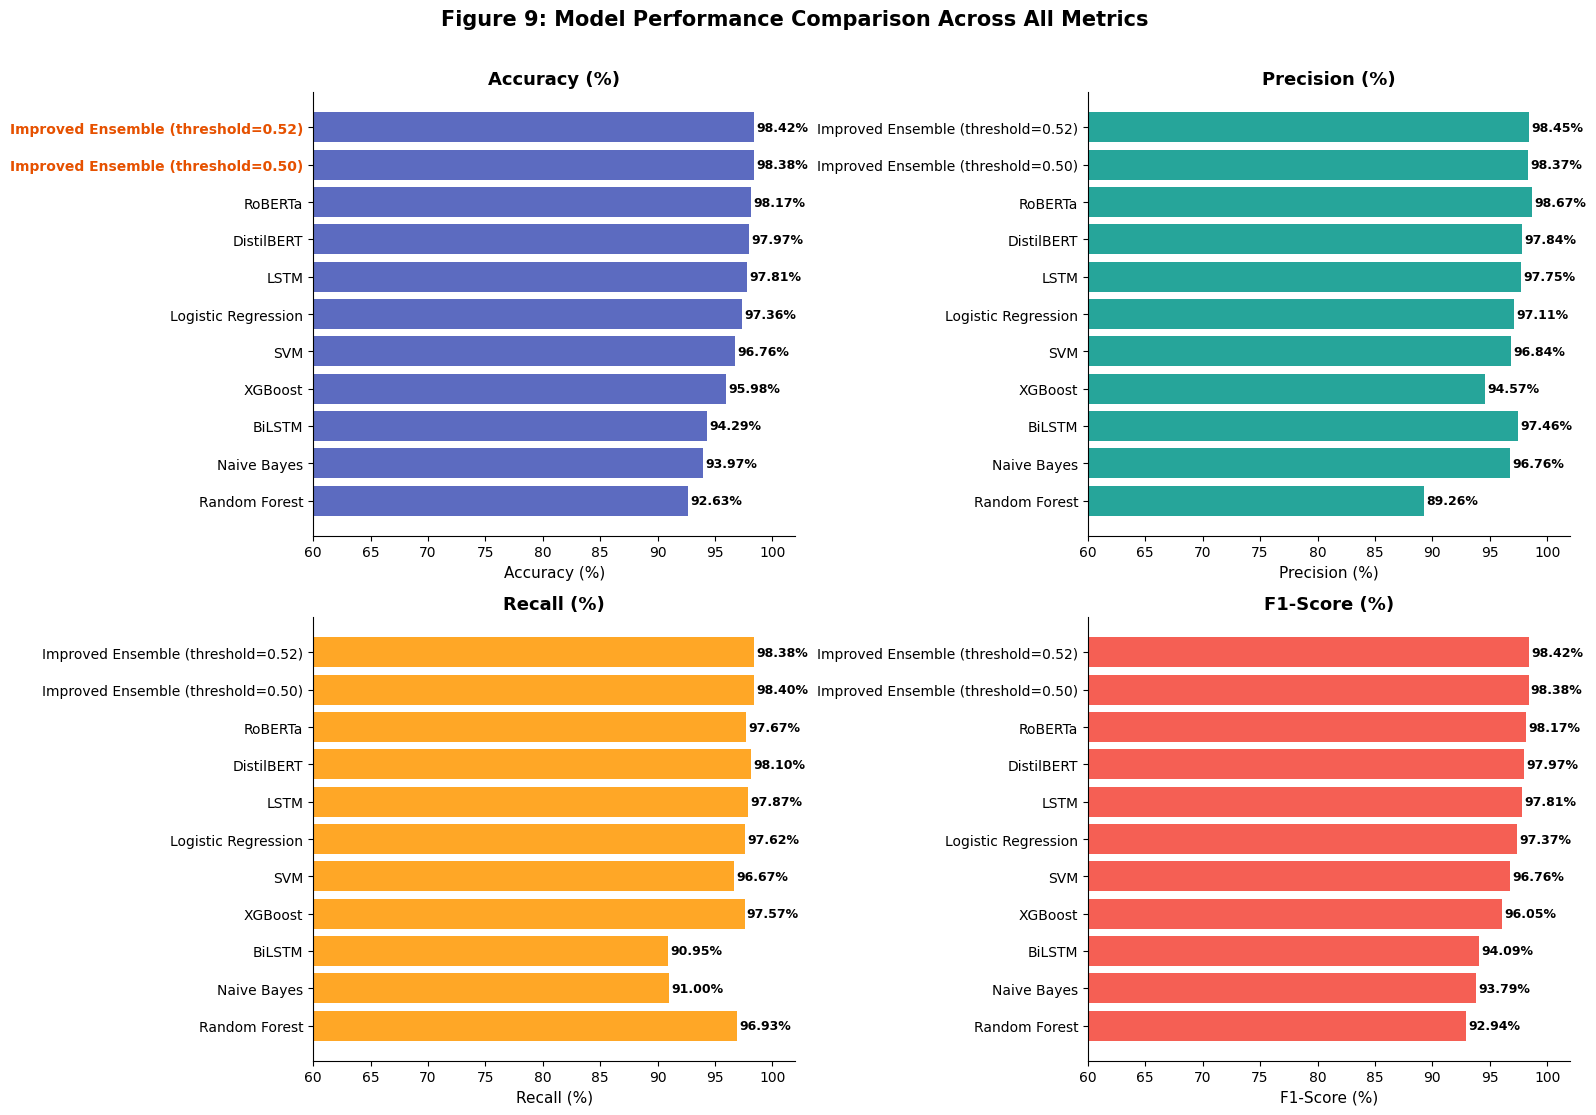

In [82]:
# ── Fig 9: Side-by-side metric comparison bar chart ──────────────
models_sorted = results_df['Model'].tolist()
metrics_to_plot = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
metric_colors   = ['#3F51B5', '#009688', '#FF9800', '#F44336']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, metric, color in zip(axes, metrics_to_plot, metric_colors):
    vals = results_df[metric].astype(float)
    bars = ax.barh(range(len(models_sorted)), vals,
                   color=color, alpha=0.85, edgecolor='none')
    for i, (bar, val) in enumerate(zip(bars, vals)):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', ha='left', fontsize=9, fontweight='bold')
    ax.set_yticks(range(len(models_sorted)))
    ax.set_yticklabels(models_sorted, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlim(60, 102)
    ax.spines[['top','right']].set_visible(False)
    # Highlights improved model
    for i, m in enumerate(models_sorted):
        if 'Improved' in m:
            axes[0].get_yticklabels()[i].set_fontweight('bold')
            axes[0].get_yticklabels()[i].set_color('#E65100')

plt.suptitle('Figure 9: Model Performance Comparison Across All Metrics',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


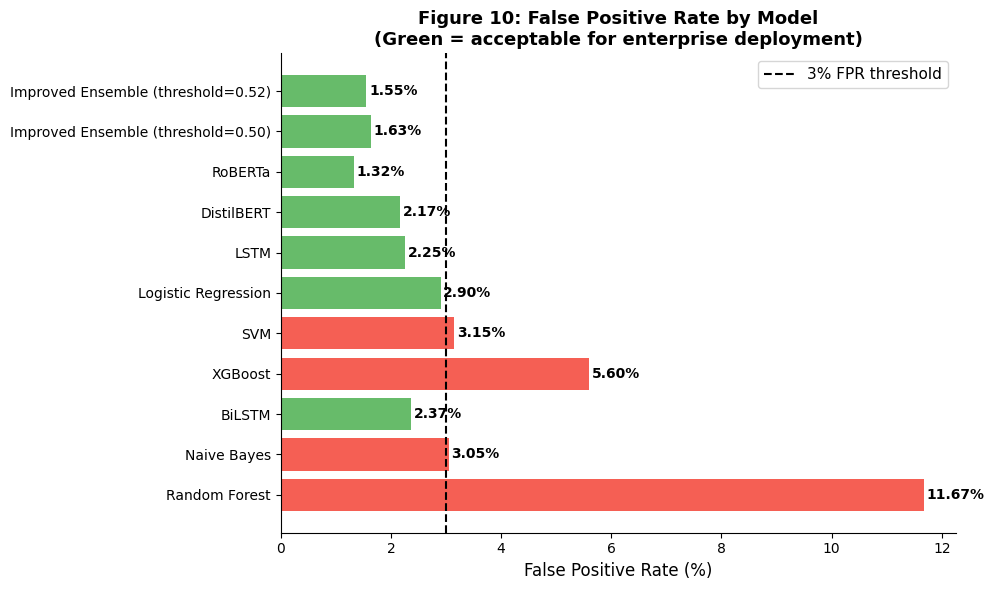

In [83]:
# ── Fig 10: False Positive Rate comparison (critical metric) ──────
fpr_vals = results_df['FPR (%)'].astype(float)
colors_fpr = ['#F44336' if v > 3 else '#4CAF50' for v in fpr_vals]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(models_sorted)), fpr_vals, color=colors_fpr,
               alpha=0.85, edgecolor='none')
for bar, val in zip(bars, fpr_vals):
    ax.text(val + 0.05, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='left', fontsize=10, fontweight='bold')
ax.axvline(3, color='black', linewidth=1.5, linestyle='--', label='3% FPR threshold')
ax.set_yticks(range(len(models_sorted)))
ax.set_yticklabels(models_sorted, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('False Positive Rate (%)', fontsize=12)
ax.set_title('Figure 10: False Positive Rate by Model\n(Green = acceptable for enterprise deployment)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig10_fpr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


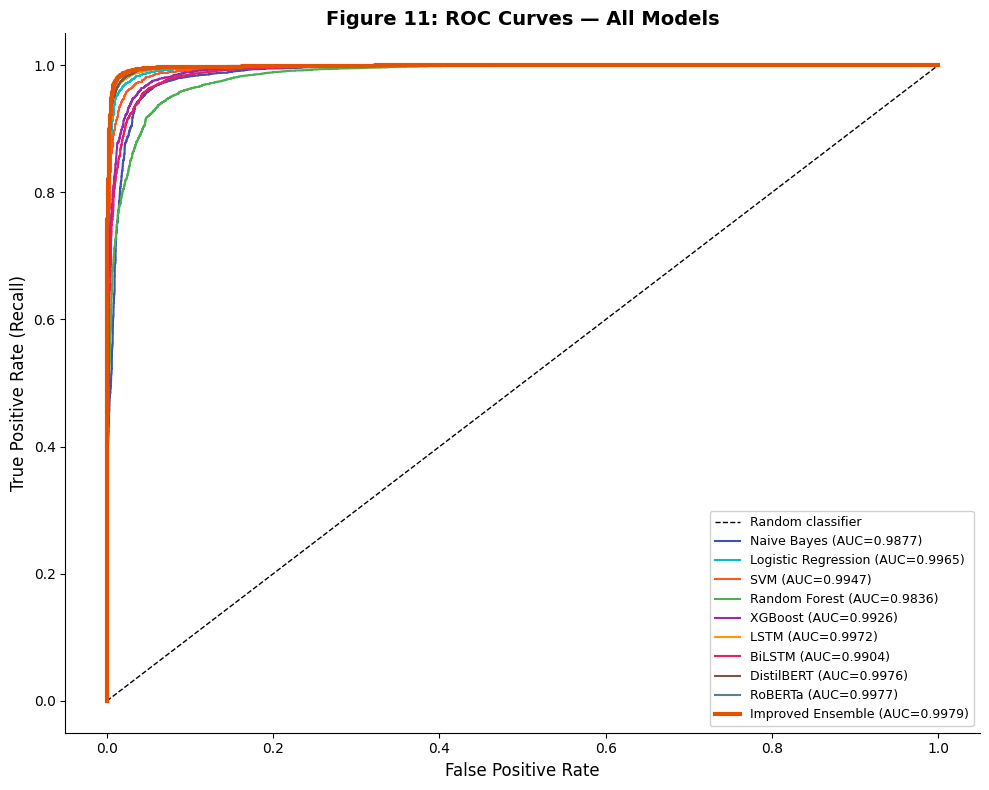

In [84]:
# ── Fig 11: ROC Curves — all models ──────────────────────────────
all_probs = {
    'Naive Bayes':          nb_prob,
    'Logistic Regression':  lr_prob,
    'SVM':                  svm_prob,
    'Random Forest':        rf_prob,
    'XGBoost':              xgb_prob,
    'LSTM':                 lstm_prob,
    'BiLSTM':               bilstm_prob,
    'DistilBERT':           db_prob,
    'RoBERTa':              rb_prob,
    'Improved Ensemble':    meta_prob_test,
}

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')

for (name, prob), color in zip(all_probs.items(), MODEL_COLORS + ['#E65100']):
    fpr_roc, tpr_roc, _ = roc_curve(y_test, prob)
    roc_auc_val = auc(fpr_roc, tpr_roc)
    lw = 3 if 'Improved' in name else 1.5
    ls = '-' if 'Improved' in name else '-'
    ax.plot(fpr_roc, tpr_roc, linewidth=lw, linestyle=ls, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Figure 11: ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()



RoBERTa (best individual baseline):
  True Negatives  (Legit correctly identified): 5,921
  False Positives (Legit wrongly flagged):      79
  False Negatives (Phishing missed):            140
  True Positives  (Phishing correctly caught):  5,860

Improved Ensemble (threshold=0.52):
  True Negatives  (Legit correctly identified): 5,907
  False Positives (Legit wrongly flagged):      93
  False Negatives (Phishing missed):            97
  True Positives  (Phishing correctly caught):  5,903


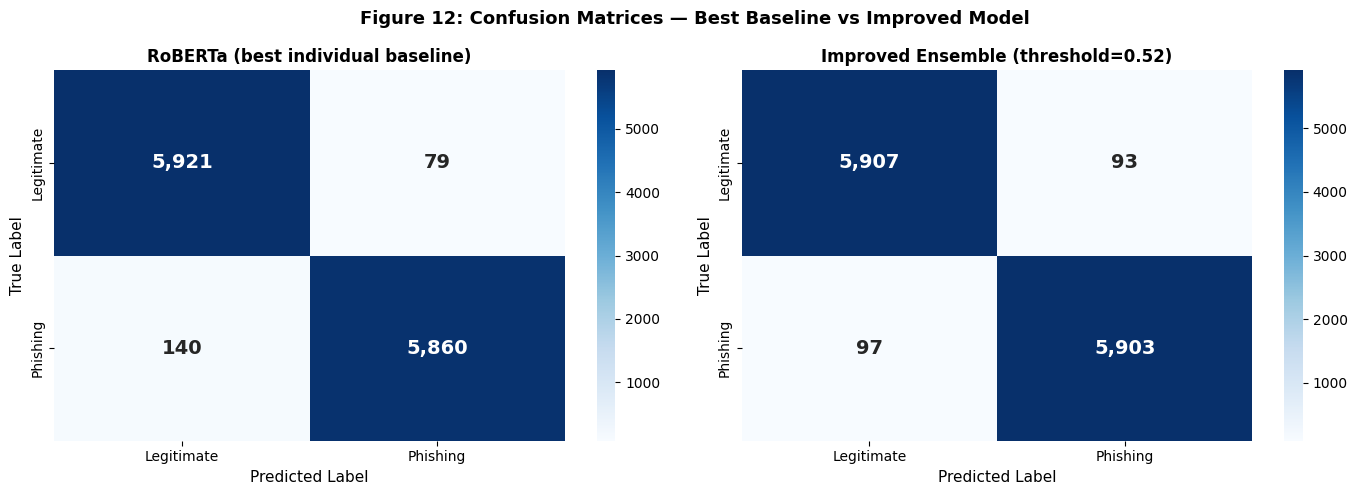

In [85]:
# ── Fig 12: Confusion matrices — RoBERTa vs Improved Ensemble ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in [
    (axes[0], (rb_prob >= 0.5).astype(int), 'RoBERTa (best individual baseline)'),
    (axes[1], meta_pred_opt,                f'Improved Ensemble (threshold={best_threshold:.2f})')
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}:")
    print(f"  True Negatives  (Legit correctly identified): {tn:,}")
    print(f"  False Positives (Legit wrongly flagged):      {fp:,}")
    print(f"  False Negatives (Phishing missed):            {fn:,}")
    print(f"  True Positives  (Phishing correctly caught):  {tp:,}")

plt.suptitle('Figure 12: Confusion Matrices — Best Baseline vs Improved Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

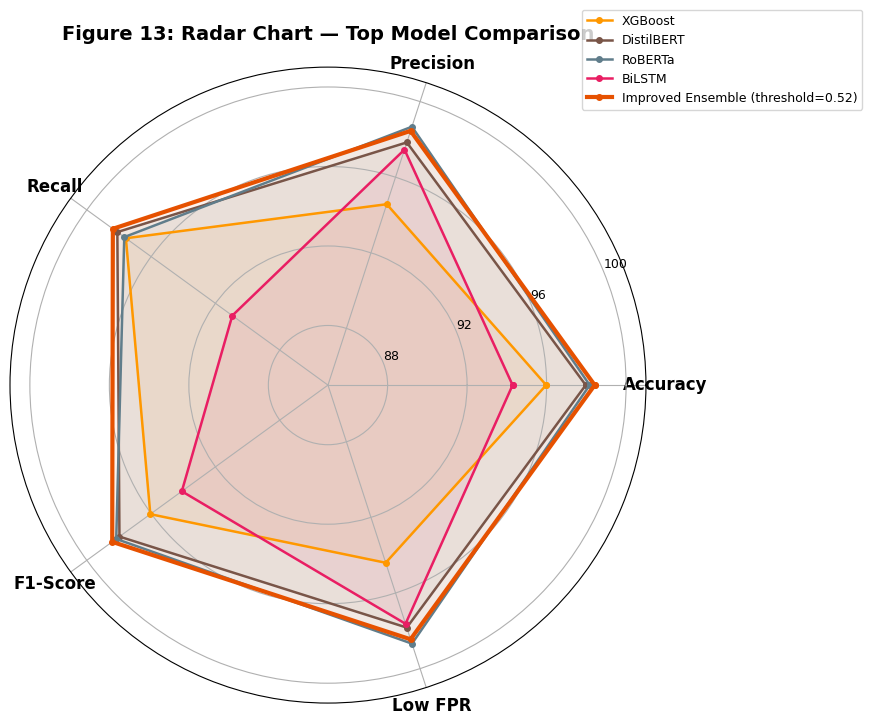

In [86]:
# ── Fig 13: Radar chart — multi-metric model comparison ──────────
import matplotlib.patches as mpatches

top_models = ['XGBoost', 'DistilBERT', 'RoBERTa', 'BiLSTM',
              f'Improved Ensemble (threshold={best_threshold:.2f})']

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Low FPR']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_radar = ['#FF9800','#795548','#607D8B','#E91E63','#E65100']

for model_name, color in zip(top_models, colors_radar):
    row = results_df[results_df['Model']==model_name]
    if row.empty: continue
    acc   = float(row['Accuracy (%)'])
    prec  = float(row['Precision (%)'])
    rec   = float(row['Recall (%)'])
    f1    = float(row['F1-Score (%)'])
    fpr_r = 100 - float(row['FPR (%)'])
    values = [acc, prec, rec, f1, fpr_r]
    values += values[:1]
    lw = 3 if 'Improved' in model_name else 1.8
    ax.plot(angles, values, 'o-', linewidth=lw, color=color, label=model_name, markersize=4)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12, fontweight='bold')
ax.set_ylim(85, 101)
ax.set_yticks([88, 92, 96, 100])
ax.set_yticklabels(['88','92','96','100'], size=9)
ax.set_title('Figure 13: Radar Chart — Top Model Comparison', size=14,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('fig13_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


In [87]:
# ── Final summary printout for dissertation ──────────────────────
print("\n" + "█"*75)
print("  MODEL RESULTS SUMMARY")
print("█"*75)
print(results_df[['Model','Accuracy (%)','Precision (%)','Recall (%)',
                   'F1-Score (%)','FPR (%)','AUC-ROC']].to_string(index=False))

# Improvement calculation vs best individual model
best_single = results_df[~results_df['Model'].str.contains('Improved')].iloc[0]
improved    = results_df[results_df['Model'].str.contains('Improved')].iloc[0]

print(f"\n{'─'*55}")
print(f"  Best single model:   {best_single['Model']}")
print(f"  Improved model:      {improved['Model']}")
print(f"{'─'*55}")
print(f"  F1-Score improvement:  +{float(improved['F1-Score (%)'])-float(best_single['F1-Score (%)']):.2f}%")
print(f"  FPR reduction:         {float(best_single['FPR (%)'])-float(improved['FPR (%)']):.2f}pp")
print(f"  AUC-ROC improvement:   +{float(improved['AUC-ROC'])-float(best_single['AUC-ROC']):.4f}")
print(f"{'─'*55}")

print("\n✅ All figures saved. All results saved to dissertation_results_table.csv")
print("\n📁 Files generated:")
for f in sorted(os.listdir('.')):
    if f.endswith('.png') or f.endswith('.csv'):
        size = os.path.getsize(f)
        print(f"   {f:45s}  {size:>8,} bytes")



███████████████████████████████████████████████████████████████████████████
  MODEL RESULTS SUMMARY
███████████████████████████████████████████████████████████████████████████
                             Model Accuracy (%) Precision (%) Recall (%) F1-Score (%) FPR (%) AUC-ROC
Improved Ensemble (threshold=0.52)        98.42         98.45      98.38        98.42    1.55  0.9979
Improved Ensemble (threshold=0.50)        98.38         98.37       98.4        98.38    1.63  0.9979
                           RoBERTa        98.17         98.67      97.67        98.17    1.32  0.9977
                        DistilBERT        97.97         97.84       98.1        97.97    2.17  0.9976
                              LSTM        97.81         97.75      97.87        97.81    2.25  0.9972
               Logistic Regression        97.36         97.11      97.62        97.37     2.9  0.9965
                               SVM        96.76         96.84      96.67        96.76    3.15  0.9947
       

In [88]:
# ── Downloading all outputs ─────────────────────────────────────────
from google.colab import files
import zipfile

with zipfile.ZipFile('dissertation_outputs.zip', 'w') as z:
    for f in os.listdir('.'):
        if f.endswith('.png') or f.endswith('.csv'):
            z.write(f)

files.download('dissertation_outputs.zip')
print("✅ dissertation_outputs.zip downloaded — contains all figures + results table")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ dissertation_outputs.zip downloaded — contains all figures + results table
